In [1]:
import rtoml
import os
from scipy.io import loadmat
from scipy.signal import savgol_filter
import numpy as np
from pylottone import mrdhelper

import pylottone as pt
from pylottone import extract_raw_pt
import matplotlib.pyplot as plt

from pylottone.triggering import pt_ecg_jitter, extract_triggers
%matplotlib widget


In [2]:
cfg_ = 'configs/config_chla_freemax_250905.toml'
with open(cfg_, 'r') as cf:
    cfg = rtoml.load(cf)

In [3]:
ismrmrd_data_fullpath_cal = '/server/home/btasdelen/MRI_DATA/pilottone/vol1133_20250316/raw/h5/meas_MID00699_FID12627_pulseq2D_fire_spiralga_200mV_24MHz_calNoGrad.h5'
ismrmrd_data_fullpath = '/server/sdata/mri_data/chla/heart/20250905_vol001/raw/h5/meas_MID00080_pulseq_FIRE_PTon_24MHz_0dBm_vs_232025.h5'
f_pt = cfg['pilottone']['pt_freq']
remove_os = cfg['saving']['remove_os']

data_dir = os.path.join('/', *(os.path.dirname(ismrmrd_data_fullpath).split('/')[:-2]))
print(f"Data dir: {data_dir}")

raw_file = ismrmrd_data_fullpath.split('/')[-1]
ismrmrd_data_fullpath, ismrmrd_noise_fullpath = mrdhelper.siemens_mrd_finder(data_dir, '', raw_file)

acq_list, wf_list, hdr = mrdhelper.read_mrd(ismrmrd_data_fullpath)
n_acq = len(acq_list)

acq_list_cal, _, _ = mrdhelper.read_mrd(ismrmrd_data_fullpath_cal)
# get the k-space trajectory based on the metadata hash.
traj_name = hdr.userParameters.userParameterString[-1].value

# load the .mat file containing the trajectory
traj = loadmat(os.path.join(data_dir, traj_name), squeeze_me=True)

n_unique_angles = int(traj['param']['repetitions'])
pre_discard = int(traj['param']['pre_discard'])
dt = float(traj['param']['dt'])

kx = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['kx'][:,:]))
ky = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['ky'][:,:]))

data = np.array([arm.data[:,:] for arm in acq_list]).transpose(2, 0, 1)
data_cal = np.array([arm.data[:,:] for arm in acq_list_cal]).transpose(2, 0, 1)


Data dir: /server/sdata/mri_data/chla/heart/20250905_vol001
Reading /server/sdata/mri_data/chla/heart/20250905_vol001/raw/h5/meas_MID00080_pulseq_FIRE_PTon_24MHz_0dBm_vs_232025.h5...
Reading acquisitions...
There are 4320 acquisitions in the dataset.
There are 1056 waveforms in the dataset.
Finished reading /server/sdata/mri_data/chla/heart/20250905_vol001/raw/h5/meas_MID00080_pulseq_FIRE_PTon_24MHz_0dBm_vs_232025.h5 in 1.78 seconds.
Reading /server/home/btasdelen/MRI_DATA/pilottone/vol1133_20250316/raw/h5/meas_MID00699_FID12627_pulseq2D_fire_spiralga_200mV_24MHz_calNoGrad.h5...
Reading acquisitions...
There are 3600 acquisitions in the dataset.
There are 1460 waveforms in the dataset.
Finished reading /server/home/btasdelen/MRI_DATA/pilottone/vol1133_20250316/raw/h5/meas_MID00699_FID12627_pulseq2D_fire_spiralga_200mV_24MHz_calNoGrad.h5 in 1.51 seconds.


In [4]:
n_channels = data.shape[2]
sensing_coils = np.array(cfg['pilottone']['sensing_coils'], dtype=int)
mri_coils = np.arange(n_channels)
mri_coils = mri_coils[~np.isin(mri_coils, sensing_coils)]

coil_name = []

for clbl in hdr.acquisitionSystemInformation.coilLabel:
    coil_name.append(clbl.coilName)

coil_name = np.asarray(coil_name)
print(f'Coil names: {coil_name}')
print(f"Coils to be used as sniffers: {coil_name[sensing_coils]}")

f0 = hdr.experimentalConditions.H1resonanceFrequency_Hz
df = 1/(dt*data.shape[0])

t_acq_start = acq_list[0].acquisition_time_stamp*2.5e-3 # [2.5ms] -> [s]
t_acq_end = acq_list[-1].acquisition_time_stamp*2.5e-3
time_acq = np.linspace(t_acq_start, t_acq_end, n_acq) # Interpolate for TR, as TR will not be a multiple of time resolution.
time_pt = time_acq - t_acq_start
samp_time_pt = time_acq[1] - time_acq[0]

ksp_measured = data[:,:,mri_coils]
ksp_cal = data_cal[:,:,mri_coils]
ksp_sniffer  = data[:,:,sensing_coils]

## Process ECG waveform
ecg, pt_wf = mrdhelper.waveforms_asarray(wf_list, ext_as_ecg=True)
if ecg is not None:
    ecg_waveform = ecg['ecg_waveform']
    time_ecg = ecg['time_ecg'] - acq_list[0].acquisition_time_stamp*2.5e-3
    ecg_trigs = ecg['ecg_trigs']
else:
    print('No ECG waveform found, skipping the validation part.')

if 'respbeat_waveform' in pt_wf.keys():
    respbeat_waveform = pt_wf['respbeat_waveform']
    time_respbeat = pt_wf['time_respbeat'] - acq_list[0].acquisition_time_stamp*2.5e-3
# plt.figure()
# plt.plot(time_ecg, ecg_waveform)
# plt.plot(time_ecg[ecg_trigs==1], ecg_waveform[ecg_trigs==1], '*')



Coil names: ['Contour_M_Coil:1:CM21' 'Contour_M_Coil:1:CM22' 'Contour_M_Coil:1:CM23'
 'Contour_M_Coil:1:CM24' 'Contour_M_Coil:1:CM31' 'Contour_M_Coil:1:CM32'
 'Contour_M_Coil:1:CM33' 'Contour_M_Coil:1:CM34' 'Contour_M_Coil:1:CM11'
 'Contour_M_Coil:1:CM12' 'Contour_M_Coil:1:CM13' 'Contour_M_Coil:1:CM14'
 'BM_Contour_L_Coil:1:CL11' 'BM_Contour_L_Coil:1:CL12'
 'BM_Contour_L_Coil:1:CL13' 'BM_Contour_L_Coil:1:CL21'
 'BM_Contour_L_Coil:1:CL22' 'BM_Contour_L_Coil:1:CL23']
Coils to be used as sniffers: []


 ## PT correction

In [5]:

f_diff = f0 - f_pt
# ksp_measured = apply_prewhitening(np.transpose(ksp_measured, (2,0,1)), dmtx).transpose((1,2,0))
# ksp_cal = apply_prewhitening(np.transpose(ksp_cal, (2,0,1)), dmtx).transpose((1,2,0))


# ksp_measured = ksp_measured@Vrvr

pt_raw_cal, _ = extract_raw_pt(ksp_cal, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='sine', freq_correction=True, return_complex=False)
pt_raw, ksp_ptsubbed = extract_raw_pt(ksp_measured, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='wPCA', freq_correction=True, return_complex=False)


Peak is found at the edge index of [32 35 32 ... 35 34 33].
This may mean the peak is outside of the given frequency range or there is no peak at all. Returning 0.


# Plot coils and raw PT

/server/home/btasdelen/.cache/uv/archive-v0/dpYNSd5ZEP8l-RMrVAgfM/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


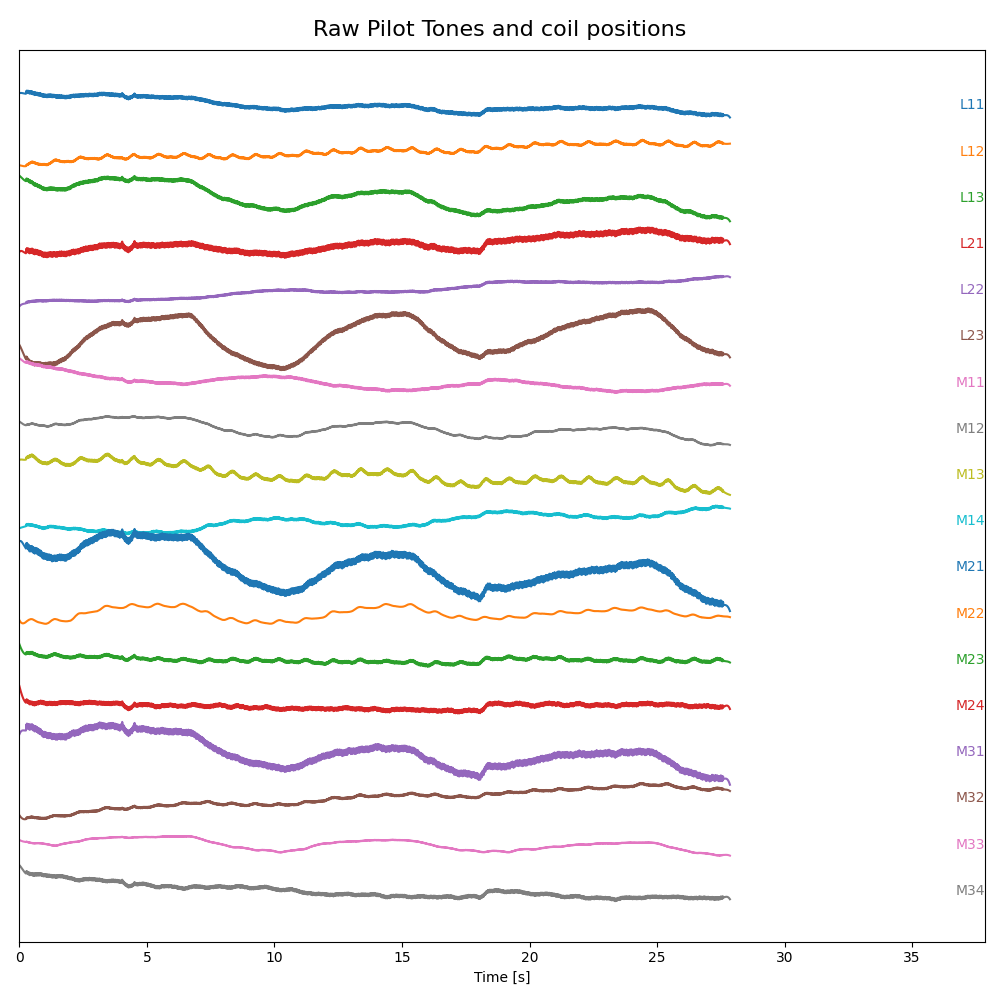

In [6]:
from matplotlib.patches import Circle
from typing import Tuple

def draw_coils(axs, coil_name, colors, all_coils=None):

    if all_coils is None:
        all_coils = {
            'Body_6:1:B11': [+1, 5], 'Body_6:1:B12': [+0, 5], 'Body_6:1:B13': [-1, 5],
            'Body_6:1:B21': [+1, 4], 'Body_6:1:B22': [+0, 4], 'Body_6:1:B23': [-1, 4],
            'Spine_18:1:S1P': [+1, +2], 'Spine_18:1:S1S': [0, +2], 'Spine_18:1:S1T': [-1, +2],
            'Spine_18:1:S2P': [+1, +1], 'Spine_18:1:S2S': [0, +1], 'Spine_18:1:S2T': [-1, +1],
            'Spine_18:1:S3P': [+1,  0], 'Spine_18:1:S3S': [0,  0], 'Spine_18:1:S3T': [-1,  0],
            'Spine_18:1:S4P': [+1, -1], 'Spine_18:1:S4S': [0, -1], 'Spine_18:1:S4T': [-1, -1]
            }
        
    for i, coil in enumerate(coil_name):
        if coil in all_coils:
            # print(f'Coil: {coil}, Position: {all_coils[coil]}')
            # Create a circle for each coil position
            circle = Circle(all_coils[coil], radius=0.5, color=colors[i], fill=False, lw=2)
            axs.text(all_coils[coil][0], all_coils[coil][1], coil[-3:], fontsize=12, ha='center', va='center')
            axs.add_patch(circle)

    axs.text(2.3, 2, 'Patient\nLeft', fontsize=14, ha='center', va='center')
    axs.text(-2.3, 2, 'Patient\nRight', fontsize=14, ha='center', va='center')
    axs.axis('equal')
    axs.set_xlim(-2, 6)
    axs.set_ylim(-3, 2)
    axs.axis('off')

def plot_rawpt(pt_raw: np.ndarray, coil_name: np.ndarray, time_pt: np.ndarray, sort: bool=True, drawcoils: bool = True) -> Tuple[plt.Figure, np.ndarray]:
    if sort:
        Isort = np.argsort(coil_name)
    else:
        Isort = np.arange(pt_raw.shape[1])
    
    spacing = np.abs(pt_raw).max()*pt_raw.shape[1]/2
    ptb = np.linspace(spacing, -spacing, pt_raw.shape[1])
    if drawcoils:
        f, axs = plt.subplots(1,2)
    else: 
        f, axs = plt.subplots(1,1)
    axs = np.atleast_1d(axs)
    f.set_size_inches(10, 10)
    lines = axs[0].plot(time_pt, ptb+pt_raw[:,Isort])
    for i, coil in enumerate((coil_name)[Isort]):
        axs[0].text(time_pt[-1]+10, ptb[i]+np.mean(pt_raw[:,i]), coil[-3:], fontsize=10, ha='right', va='center', color=lines[i].get_color())
    axs[0].set_xlabel('Time [s]')

    axs[0].set_xlim(0, time_pt[-1]+10)
    axs[0].set_yticks([])
    default_colors = [line.get_color() for line in lines]
    if drawcoils:
        draw_coils(axs[1], (coil_name)[Isort], default_colors)
    plt.suptitle('Raw Pilot Tones and coil positions', fontsize=16)
    plt.tight_layout()
    return f, axs

pt_raw_filt = savgol_filter(pt_raw, 81, 3, axis=0)

spacing = np.abs(pt_raw_filt).max()*pt_raw.shape[1]/2
ptb = np.linspace(spacing, -spacing, pt_raw.shape[1])

f, axs = plot_rawpt(pt_raw_filt, coil_name[mri_coils], time_pt, sort=True, drawcoils=False)

plt.tight_layout()
plt.show()

/server/home/btasdelen/.cache/uv/archive-v0/dpYNSd5ZEP8l-RMrVAgfM/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


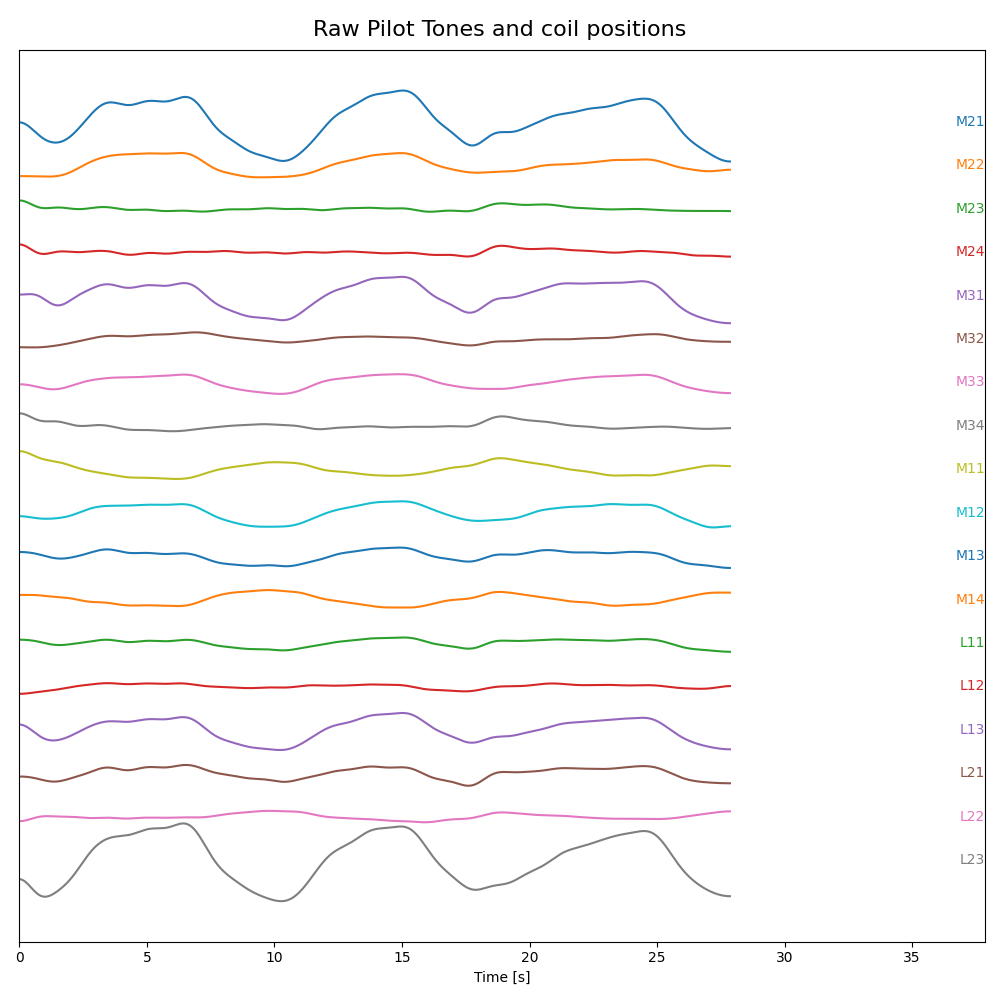

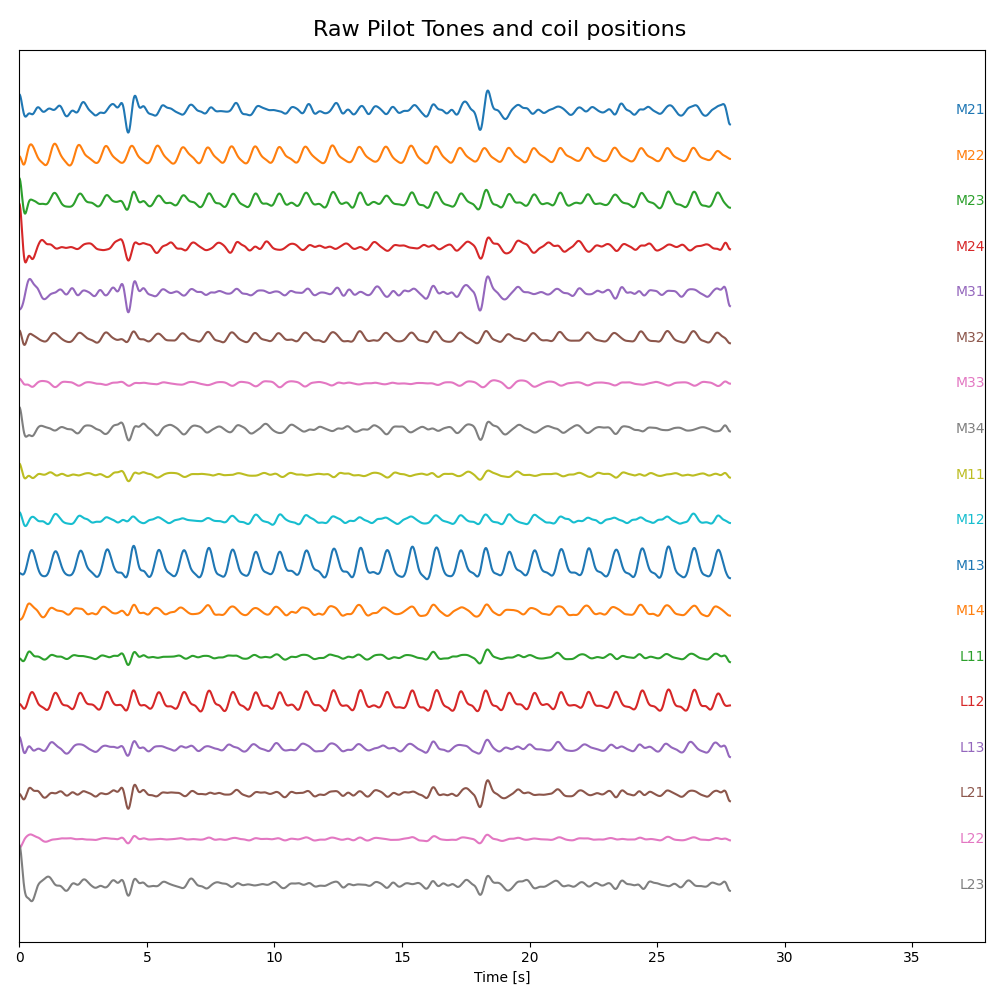

In [13]:
from pylottone.signal import designbp_tukeyfilt_freq, apply_filter_freq
f_samp = 1/samp_time_pt
n_pt_samp = pt_raw.shape[0]
filt_bp_resp = designbp_tukeyfilt_freq(cfg['pilottone']['respiratory']['freq_start'], cfg['pilottone']['respiratory']['freq_stop'], f_samp, n_pt_samp)

pt_respiratory_freqs = apply_filter_freq(pt_raw_filt, filt_bp_resp, 'symmetric')


filt_bp_cardiac = designbp_tukeyfilt_freq(cfg['pilottone']['cardiac']['freq_start'], 4, f_samp, n_pt_samp)
pt_cardiac_freqs = apply_filter_freq(pt_raw_filt, filt_bp_cardiac, 'symmetric')

plot_rawpt(pt_respiratory_freqs*3, coil_name[mri_coils], time_pt, sort=False, drawcoils=False)
_, axs = plot_rawpt(pt_cardiac_freqs*20, coil_name[mri_coils], time_pt, sort=False, drawcoils=False)
# axs[0].vlines([88.817, 89.13],  ymin=-1.5e-3, ymax=1.5e-3, color='k', lw=1, linestyle='--')
# axs[0].vlines([88.85, 89.166],  ymin=-1.5e-3, ymax=1.5e-3, color='r', lw=1, linestyle='--')

# card_chs = [0, 1, 2, 4, 5, 8]
# plt.figure()
# plt.subplot(2,1,1)
# plt.plot(time_pt, pt_respiratory_freqs/np.percentile(pt_respiratory_freqs, 99, axis=0), label='Respiratory Pilot Tone')
# plt.subplot(2,1,2)
# plt.plot(time_pt, pt_cardiac_freqs[:, card_chs]/np.percentile(np.abs(pt_cardiac_freqs[:, card_chs]), 99, axis=0), label='Cardiac Pilot Tone')
# plt.legend(coil_name[card_chs])


In [14]:
print(ecg_trigs.sum())

0


Text(0.5, 0, 'Time [s]')

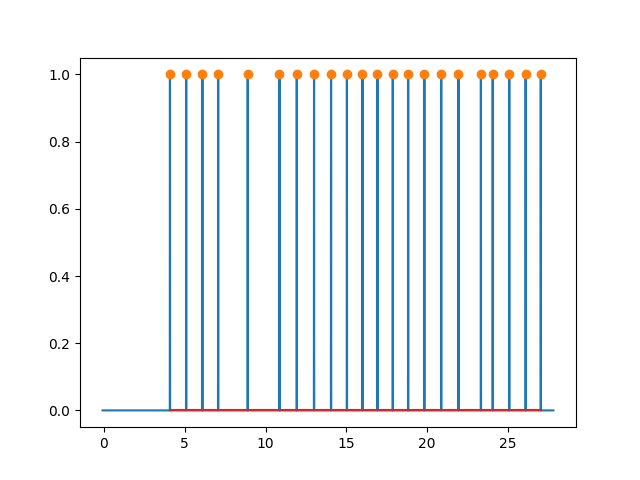

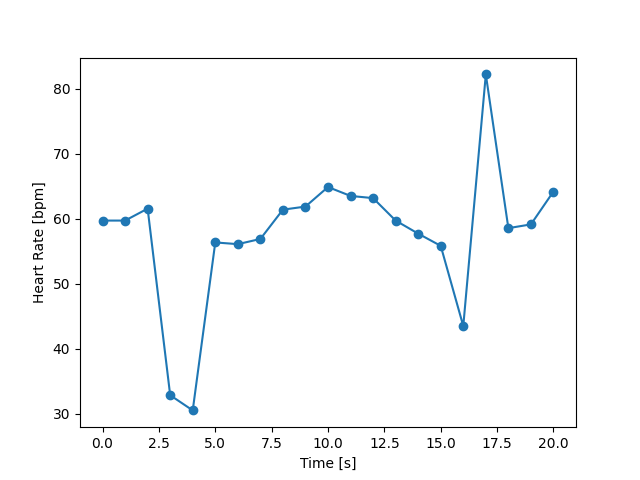

In [9]:
plt.figure()
plt.plot(time_ecg, ecg['ecg_waveform'])
plt.stem(time_ecg[ecg_trigs==1], np.ones((ecg_trigs==1).sum()), '*', label='ECG Triggers')

ecg_trig_diffs = np.diff(time_ecg[ecg_trigs==1])
plt.figure()
plt.plot(60/ecg_trig_diffs, marker='o')
plt.ylabel('Heart Rate [bpm]')
plt.xlabel('Time [s]')





(<Figure size 1000x1000 with 1 Axes>,
 array([<Axes: xlabel='Time [s]'>], dtype=object))

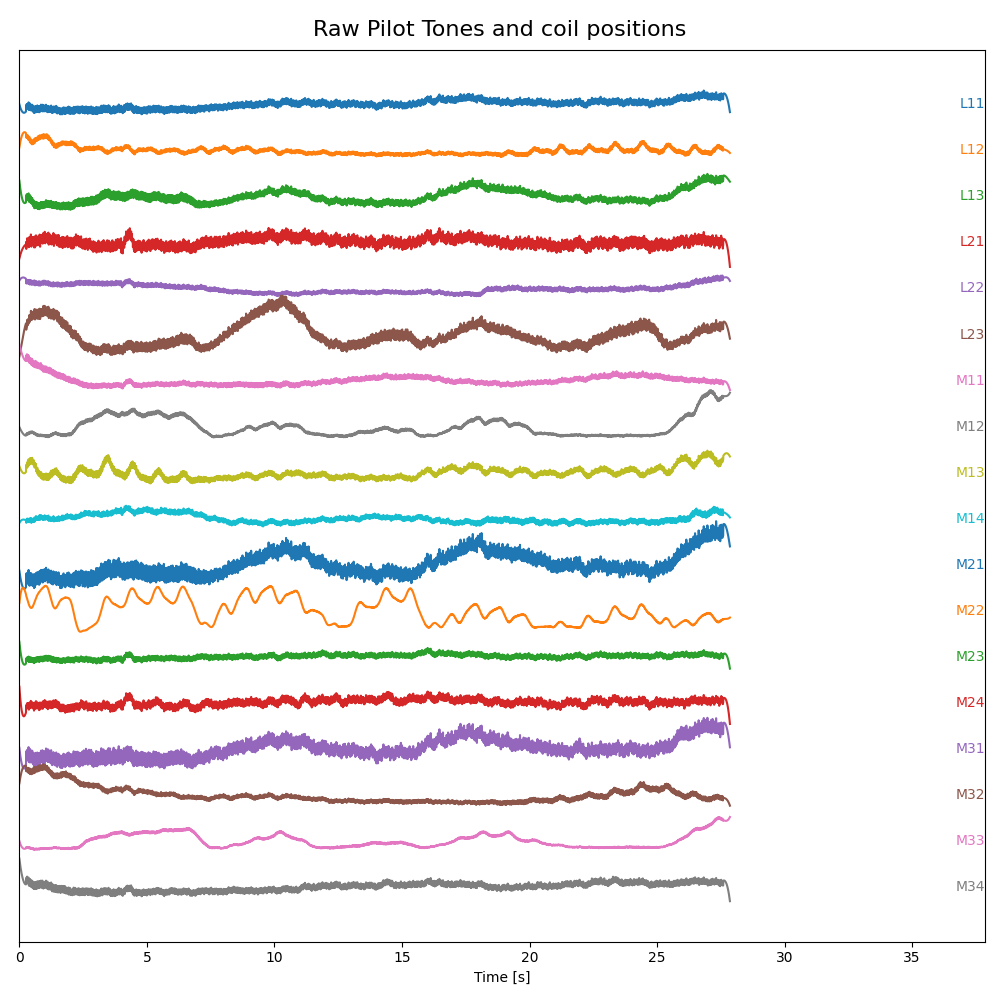

In [11]:
plot_rawpt(savgol_filter(np.abs(pt_raw) - np.mean(np.abs(pt_raw), axis=0, keepdims=True), 81, 3, axis=0), coil_name, time_pt, sort=True, drawcoils=False)

In [36]:
coil_name[5]

np.str_('Body_6:1:B22')

 ## QA and ECG PT Jitter

Using Contour_M_Coil:1:CM13 as the initial cardiac coil.
Number of channels selected for respiratory PT: 10
Number of channels selected for cardiac PT: 4
Rejection ratio for pt peaks is 0.00 percent.

Rejection ratio for derivative pt peaks is 0.00 percent.

Peak difference 344.2 ± 75.9
Derivative peak difference 140.2 ± 19.9
Number of ECG triggers: 22.
Number of PT triggers: 27.
Number of missed PT triggers: 0.
Number of extraneous PT triggers: 2.
Number of derivative PT triggers: 27.
Number of missed derivative PT triggers: 1.
Number of extraneous derivative PT triggers: 3.


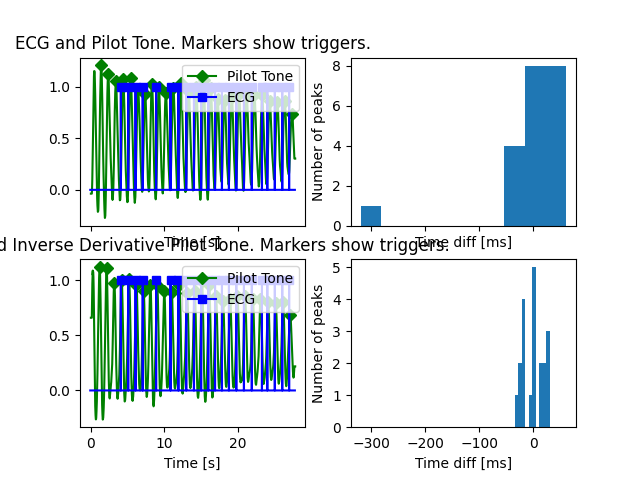

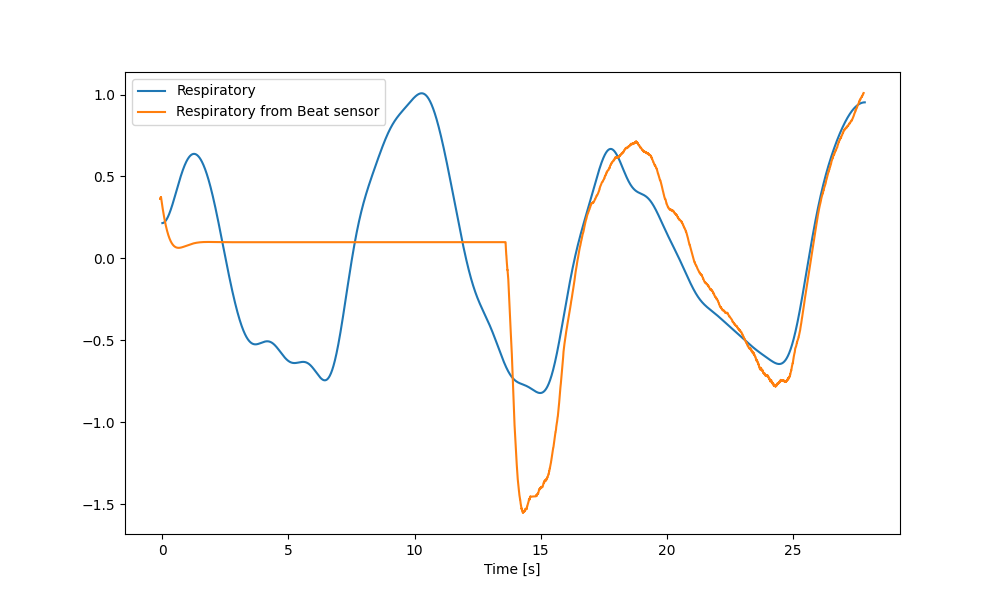

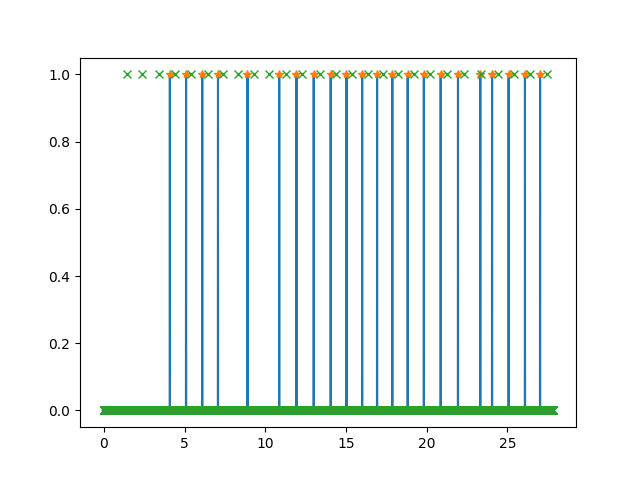

In [24]:
import importlib
import pylottone
import pylottone.pt

importlib.reload(pylottone)
importlib.reload(pylottone.pt)

f_samp = 1/samp_time_pt # [Hz]
print(f"Using {cfg['pilottone']['cardiac']['initial_channel']} as the initial cardiac coil.")
pt_extract_params = {'golay_filter_len': cfg['pilottone']['golay_filter_len'],
                    'respiratory': {
                            'freq_start': cfg['pilottone']['respiratory']['freq_start'],
                            'freq_stop': cfg['pilottone']['respiratory']['freq_stop'],
                            'corr_threshold': cfg['pilottone']['respiratory']['corr_threshold'],
                            'corr_init_ch': cfg['pilottone']['respiratory']['initial_channel'],
                            'separation_method': 'pca' #cfg['pilottone']['respiratory']['separation_method'], # 'sobi', 'pca'
                    },
                    'cardiac': {
                                'freq_start': cfg['pilottone']['cardiac']['freq_start'],
                                'freq_stop': cfg['pilottone']['cardiac']['freq_stop'],
                                'corr_threshold': 0.9, #cfg['pilottone']['cardiac']['corr_threshold'],
                                'corr_init_ch': np.nonzero(coil_name == cfg['pilottone']['cardiac']['initial_channel'])[0][0],                           
                                'separation_method': 'sobi', #cfg['pilottone']['cardiac']['separation_method'], # 'sobi', 'pca'
                                'num_lags': 375, # SOBI number of lags
                    },
                    'debug': {
                        'selected_coils': cfg['pilottone']['debug']['selected_coils'],
                        'coil_legend': coil_name[mri_coils],
                        'show_plots': cfg['pilottone']['debug']['show_plots'],
                        'no_normalize': cfg['pilottone']['debug']['no_normalize'],
                    }
                }

sg_filter_len = 81

cal_select = (time_pt > 40) & (time_pt < 60)
pt_respiratory, pt_cardiac = pt.extract_pilottone_navs(pt_raw, f_samp, pt_extract_params)
# Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw[cal_select,:], f_samp, pt_extract_params)
# Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params)
# pt_respiratory, pt_cardiac = pt.apply_pt_calib(pt_raw, Vresp, accept_list_resp, Vcard.T, accept_list_cardiac, f_samp, pt_extract_params)
pt_respiratory /= np.percentile(pt_respiratory, 99)
time_pt2 = time_pt

pt_cardiac = -1*cfg['pilottone']['cardiac']['sign']*pt_cardiac
pt_cardiac[:20] = pt_cardiac[20]
pt_cardiac[-20:] = pt_cardiac[-20]
pt_cardiac -= np.percentile(pt_cardiac, 10)
pt_cardiac /= np.percentile(pt_cardiac, 95)

pt_cardiac_filtered = savgol_filter(pt_cardiac, sg_filter_len, 3, axis=0)
pt_cardiac_derivative = np.hstack((0, np.diff(pt_cardiac_filtered)/(time_pt[1] - time_pt[0])))
pt_cardiac_derivative[:20] = pt_cardiac_derivative[20]
pt_cardiac_derivative[-20:] = pt_cardiac_derivative[-20]
pt_cardiac_derivative -= np.percentile(pt_cardiac_derivative, 10)
pt_cardiac_derivative /= np.percentile(pt_cardiac_derivative, 98)

pt_cardiac_trigs = extract_triggers(time_pt2, pt_cardiac, skip_time=1, prominence=0.4, max_hr=160)
pt_derivative_trigs = extract_triggers(time_pt2, pt_cardiac_derivative, skip_time=1, prominence=0.5, max_hr=160)

if ecg is not None:
    _,_ = pt_ecg_jitter(time_pt2, pt_cardiac, pt_cardiac_derivative,
                        time_ecg, ecg['ecg_waveform'], 
                        pt_cardiac_trigs=pt_cardiac_trigs, pt_derivative_trigs=pt_derivative_trigs, ecg_trigs=ecg_trigs, 
                        skip_time=1, show_outputs=cfg['pilottone']['show_outputs'])
    plt.figure(figsize=(10, 6))
    plt.plot(time_pt2, pt_respiratory, label='Respiratory')
    plt.plot(time_respbeat, respbeat_waveform, label='Respiratory from Beat sensor')
    plt.legend()
    plt.xlabel('Time [s]')
    plt.show()
elif ecg is None and cfg['pilottone']['show_outputs']:
    pt_trig_diffs = np.diff(time_pt[pt_derivative_trigs==1])

    fig, axs = plt.subplots(3,1, figsize=(10, 6), sharex=True)
    axs[0].plot(time_pt2, pt_cardiac, label='Cardiac')
    axs[0].plot(time_pt2, pt_cardiac_derivative, label='Cardiac Derivative')
    axs[0].plot(time_pt2[pt_cardiac_trigs==1], pt_cardiac[pt_cardiac_trigs==1], '*', label='Cardiac Triggers')
    axs[0].plot(time_pt2[pt_derivative_trigs==1], pt_cardiac_derivative[pt_derivative_trigs==1], '*', label='Cardiac Derivative Triggers')
    axs[0].set_title('Cardiac Triggers')
    axs[0].legend()
    axs[1].plot(time_pt[pt_derivative_trigs==1][1:], 60/pt_trig_diffs, marker='o')
    axs[1].set_ylabel('Heart Rate [bpm]')
    axs[2].plot(time_pt2, pt_respiratory, label='Respiratory')
    axs[2].set_title('Respiratory')
    axs[2].set_xlabel('Time [s]')
    axs[2].legend()

    plt.show()

